<a href="https://colab.research.google.com/github/GabCAD92/Machine-learning-tasks/blob/main/DNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Supervised Machine Learning
## Supervised Learning: DNN practice: digits classification

This lesson implements __Multilayer Perceptron (MLP)__ and __Deep Neural Network (DNN)__ in __digits classification__ application using __tensorflow__.


### Professor:

<img src="https://www.sorocaba.unesp.br/Home/Graduacao/EngenhariadeControleeAutomacao/alexandre/alex_marta1_small.jpg" width="100" style="float: left; margin-right: 5px;" border="10px" />

  __Prof. Dr. Alexandre da Silva Simões__ <br>
  Control and Automation Engineering Department (DECA) <br>
  Institute of Science and Technology<br>
  São Paulo State University (Unesp) <br>
  Campus Sorocaba <br>
  www.sorocaba.unesp.br/professor/assimoes

<br/>

References:
* Géron, A. "Hands-On Machine Learning with Scikit-Learn and TensorFlow", O’Reilly Media Inc., Sebastopol, CA, EUA.
* The MINIST dataset: http://yann.lecun.com/exdb/mnist/
* Building a simple NN with Keras: https://github.com/wxs/keras-mnist-tutorial/blob/master/MNIST%20in%20Keras.ipynb
* CNN for mnist digit recognition: https://towardsdatascience.com/a-simple-2d-cnn-for-mnist-digit-recognition-a998dbc1e79a


# Table of Contents


1. Introduction <br>
    1.1. TensorFlow <br>
    1.2. The MNIST digits classification dataset <br>
	1.3. Loading the dataset <br>
2. Preprocessing data <br>
	2.1. Balancing classes <br>
	2.2. Preparing input and output vectors <br>
3. Multilayer Perceptron (MLP) <br>
  	3.1. Architecture <br>
	3.2. Sequential model <br>
	3.3. Functional Keras API model <br>
  	3.4. Visualizing models: Keras <br>
  	3.5. Visualizing models: Visual Keras <br>
4. MLP Training <br>
	4.1. Compilation <br>
 	4.2. Training <br>
	4.3. Improving the NN training <br>
 	4.3. Evaluation <br>
5. Deep Neural Networks (DNN) <br>
  	5.1. Architecture <br>
	5.2. Visualizing model: Keras <br>
      5.3. Visualizing model: Visual Keras <br>
6. DNN Training <br>
	6.1. Compilation <br>
 	6.2. Evaluation <br>
7. Final considerations <br>
 <br>


____

# 1. Introduction

## 1.1. TensorFlow

<center>

  <img src="https://drive.google.com/uc?id=1h58H6gQj8hb2pCfJrbfFSokgEFN7LM8v" width="300" style="float: left; margin-right: 5px;" border="0px" />

</center>

__TensorFlow__ (see https://en.wikipedia.org/wiki/TensorFlow) is the Machine Learning (ML) open source library developed by Google. Its a symbolic math library based on dataflow and differentiable programming.  It has a particular focus on training and inference using __Deep Neural Networks (DNNs)__. TensorFlow can be used in a wide variety of programming languages such as Python, Javascript, C++, and Java. __Keras__ is a Python API for (and today fully integrated to) TensorFlow library. In this context, tensors are multi-dimensional (numpy) arrays with a uniform type (dtype).




In [1]:
# First of all, loading a lot of libraries...

import numpy as np
import matplotlib.pyplot as plt
import tensorflow
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
print(tensorflow.__version__)


2.19.0


## 1.2. MNIST digits classification dataset


<div><center><img src="https://upload.wikimedia.org/wikipedia/commons/2/27/MnistExamples.png" width="500"></center></div>

The MNIST (*Modified National Institute of Standards and Technology*) database is a <b>handwritten digits database</b> with 60,000 training examples and 10,000 test examples. The dataset stores 28x28 grayscale pixels images of the 10 digits (0-9) in NumPy array format. The digits have been size-normalized and centered in a fixed-size image.  <br>

## 1.3. Loading the dataset

The dataset is available as a toy dataset in keras. It can be loaded using: <br>

`(X_train, Y_train), (X_test, Y_test) = tensorflow.keras.datasets.mnist.load_data()` <br>

where:

* X_train: is a uint8 NumPy array of grayscale image data with shapes (60000, 28, 28), containing the training data. Pixel values range: 0 to 255;

* Y_train: is a uint8 NumPy array of digit labels (integers in range 0-9) with shape (60000,) for the training data;

* X_test: is a uint8 NumPy array of grayscale image data with shapes (10000, 28, 28), containing the test data. Pixel values range: 0 to 255;

* Y_test: is a uint8 NumPy array of digit labels (integers in range 0-9) with shape (10000,) for the test data.


In [3]:
# Importing the mnist dataset...

# Option 1: downloading from the internet....
#(X_train, Y_train), (X_test, Y_test) = tensorflow.keras.datasets.mnist.load_data()

# Option 2: Loading local file...
import pandas as pd
from google.colab import drive
drive.mount('/content/drive/')
path = '/content/drive/My Drive/Colab Notebooks/mnist.npz'

with np.load(path) as data:
    X_train = data['x_train']
    Y_train = data['y_train']
    X_test = data['x_test']
    Y_test = data['y_test']


print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)


Mounted at /content/drive/
(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


Let's see some of the training examples:

Training example 0: 5


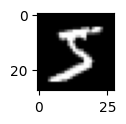

Training example 1: 0


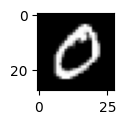

Training example 2: 4


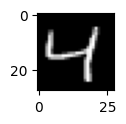

Training example 3: 1


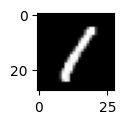

In [4]:

# Showing some of the training examples and their labels...

plt.rcParams['figure.figsize'] = (1,1)          # Display figures smaller...
for i in range (0,4):
  print("Training example " + str(i) + ": " + str(Y_train[i]))
  plt.imshow(X_train[i], cmap='gray', vmin=0, vmax=255)
  plt.show()


And some of the test examples:

Test example 0: 7


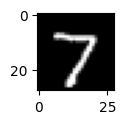

Test example 1: 2


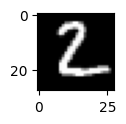

Test example 2: 1


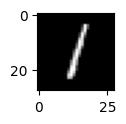

In [5]:
# Showing some of the test samples and their labels...

for i in range (0,3):
  print("Test example " + str(i) + ": " + str(Y_test[i]))
  plt.imshow(X_test[i], cmap='gray', vmin=0, vmax=255)
  plt.show()


# 2. Data preprocessing

## 2.1. Balancing classes

**Counting samples.** Let's check how many samples of each class we have in our training data. This will be usefull to identify potentially subsampled classes.

In [6]:
# Counting the number of samples that belong to each class (0,1,...9)

unique, counts = np.unique(Y_train, return_counts=True)
print ("Average --> ", int(len(Y_train)/len(unique)))
print ("Train ---> ", dict(zip(unique, counts)), "\n")


Average -->  6000
Train --->  {np.uint8(0): np.int64(5923), np.uint8(1): np.int64(6742), np.uint8(2): np.int64(5958), np.uint8(3): np.int64(6131), np.uint8(4): np.int64(5842), np.uint8(5): np.int64(5421), np.uint8(6): np.int64(5918), np.uint8(7): np.int64(6265), np.uint8(8): np.int64(5851), np.uint8(9): np.int64(5949)} 



**Balancing classes.** The classes are relatively well balanced, but we can improve it. <br>
The function `compute_class_weight` estimates class weights for balancing unbalanced datasets. Example:

`class_weights = compute_class_weight(class_weight = "balanced", classes = np.unique(Y), y = Y)`

Parameters:

* class_weight dict: `balanced` or `None`. If balanced, class weights will be given by `n_samples / (n_classes * np.bincount(y))`. If a dictionary is given, keys are classes and values are corresponding class weights. If None is given, the class weights will be uniform;

* classes ndarray: array of the classes occurring in the data, as given by `np.unique(Y)` with Y the original class labels;

* Y: array of original class labels per sample;

Return:

* `class_weight_vect`: array with class_weight_vect[i] the weight for i-th class.


In [7]:
# Compute the balance of the classes

class_weights = compute_class_weight(class_weight = "balanced", classes = np.unique(Y_train), y = Y_train)
class_weights = dict(zip(np.unique(Y_train), np.around(class_weights,3)))

print ("Number of examples (av:",str(int(len(Y_train)/len(unique))),"): ", dict(zip(unique, counts)))
print ("Class weights to balance:       ", class_weights)


Number of examples (av: 6000 ):  {np.uint8(0): np.int64(5923), np.uint8(1): np.int64(6742), np.uint8(2): np.int64(5958), np.uint8(3): np.int64(6131), np.uint8(4): np.int64(5842), np.uint8(5): np.int64(5421), np.uint8(6): np.int64(5918), np.uint8(7): np.int64(6265), np.uint8(8): np.int64(5851), np.uint8(9): np.int64(5949)}
Class weights to balance:        {np.uint8(0): np.float64(1.013), np.uint8(1): np.float64(0.89), np.uint8(2): np.float64(1.007), np.uint8(3): np.float64(0.979), np.uint8(4): np.float64(1.027), np.uint8(5): np.float64(1.107), np.uint8(6): np.float64(1.014), np.uint8(7): np.float64(0.958), np.uint8(8): np.float64(1.025), np.uint8(9): np.float64(1.009)}


## 2.2. Preparing input and output vectors

**Input vector.** Instead of receiveing a 28x28 input vector, our MLP will receive a 784-dimension X vector for each training example. In this way, we must reshape our input vector. We also need to scale the values to the range [0,1] instead of [0,255].


In [8]:
# Reshape input and output vectors

size = X_train.shape[1] * X_train.shape[2]    #Prepare the 28x28 = 784-dimension vector
X_reshaped = X_train.reshape(X_train.shape[0], size)
X_test_reshaped = X_test.reshape(X_test.shape[0], size)

# Change vector elements to float 32
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")
X_reshaped = X_reshaped.astype('float32')
X_test_reshaped = X_test_reshaped.astype('float32')

# Make sure images have shape (28, 28, 1)
X_train = np.expand_dims(X_train, -1)
X_test = np.expand_dims(X_test, -1)

# Scale values to the range [0,1] instead of [0,255]
X_train /= 255
X_test /= 255
X_reshaped /= 255
X_test_reshaped /= 255

print("Training matrix reshaped", X_reshaped.shape)
print("Testing matrix reshaped", X_test_reshaped.shape)


Training matrix reshaped (60000, 784)
Testing matrix reshaped (10000, 784)


**Output vector.** We will adopt here the *one-hot encoded* output. That is:

```
class 0 -> [1, 0, 0, 0, 0, 0, 0, 0, 0]
class 1 -> [0, 1, 0, 0, 0, 0, 0, 0, 0]
class 2 -> [0, 0, 1, 0, 0, 0, 0, 0, 0]
class 3 -> [0, 0, 0, 1, 0, 0, 0, 0, 0]
...
class 9 -> [0, 0, 0, 0, 0, 0, 0, 0, 1]
```

The function _tensorflow.keras.utils.to_categorical_ generates a binary matrix representation of the input:

In [9]:
# Generate the one-hot encoded output vector

NUM_CLASSES = 10      # Number of classes that will be considered (output vector size)

# Encoding...
Y_onehot = to_categorical(Y_train, NUM_CLASSES)
Y_test_onehot = to_categorical(Y_test, NUM_CLASSES)

# Print vectors shape:
print("Training matrix shape", Y_onehot.shape)
print("Testing matrix shape", Y_test_onehot.shape)

# Show some of the outputs...
for i in range(0, 6):
  print("Example: " + str(i) + ", class: " + str(Y_train[i]) + ": ")
  print(Y_onehot[i])


Training matrix shape (60000, 10)
Testing matrix shape (10000, 10)
Example: 0, class: 5: 
[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
Example: 1, class: 0: 
[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Example: 2, class: 4: 
[0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
Example: 3, class: 1: 
[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
Example: 4, class: 9: 
[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
Example: 5, class: 2: 
[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]


# 3. Multilayer Perceptron (MLP)

## 3.1. Architecture

Here we will build a MLP with 4 layers (input layer, 2 hidden layers and output layer) using dense (or *fully connected*) layers. In this kind of layer, each neuron is connected to all neurons in the previous layer. Each neuron of the first hidden layer is connected to all pixels of the input image. <br>
We will build the network using two distinct ways:

1. Sequential model, and
2. Keras functional API.

## 3.2. Sequential model

***Sequential model.*** The first way to create a MLP is defining, sequentially, a list of layers that will be created one after the other:

```
{
# Example of sequential model
model = keras.Sequential(
    [
        layers.Dense(2, activation="relu", name="layer1"),
        layers.Dense(3, activation="relu", name="layer2"),
        layers.Dense(4, name="layer3"),
    ]
)
}
```

***When to use the sequential model?** A sequential model is appropriate when you have a simple stack of layers where each layer has exactly one input tensor and one output tensor. You should not adopt the sequential model when:

* Your network has multiple inputs or outputs;
* Your networks has a more complex topology (layers with multiple inputs or outputs, there is layer sharing, you want a model with multiple branches, etc.).

In [10]:

# Loading more libraries...

from tensorflow import keras
from tensorflow.keras.preprocessing import image
from tensorflow.keras import layers, Model, losses, optimizers, callbacks
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Input
from tensorflow.keras.utils import plot_model


In [11]:

# Creating a MLP using a sequential model...
# Softmax activation function forces the output layer to express the probability of the input data to
# belong to each network output.

model_1 = Sequential([
        layers.Dense(512, activation="relu", input_shape=(784,), name="layer1"),
        layers.Dense(512, activation="relu", name="layer2"),
        layers.Dense(10, activation="softmax", name="layer3"),
    ], name="model_1_sequential")
model_1.build()
model_1.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "model_1_sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                  │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (Dense)                  │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer3 (Dense)                  │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 669,706 (2.55 MB)

 Trainable params: 669,706 (2.55 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:

# Another syntax to create the same sequential model...

model_2 = Sequential(name="model_2_sequential")
model_2.add(Dense(512, activation='relu', input_shape=(784,), name="layer1"))
model_2.add(Dense(512, activation='relu',name="layer2"))
model_2.add(Dense(10, activation='softmax', name="layer3"))
model_2.build()
model_2.summary()


Model: "model_2_sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                  │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (Dense)                  │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer3 (Dense)                  │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 669,706 (2.55 MB)

 Trainable params: 669,706 (2.55 MB)

 Non-trainable params: 0 (0.00 B)

## 3.3. Functional Keras API model

The *Keras functional API* is a way to create models that are more flexible than those possible using the sequential model. The functional API can handle models with non-linear topology, shared layers, and even multiple inputs or outputs. The functional API is based on the idea of creating graphs of layers. <br/>

Consider the following steps to create a model:
1. Create a input object layer using the `Input` function;
2. Create a new node in the graph of layers by calling a `Layer` on you input object. The layer call action is like drawing an arrow from "inputs" to this new layer you created, that is, you are sending the inputs to this dense layer, and you get x as the output;

In [13]:

# Creating a MLP using the functional API model...
input_vector = Input(shape=(784,), name="InputLayer")                          # Creating the input graph layer
output_l2 = layers.Dense(512, activation="relu", name="layer1") (input_vector) # Insert a new graph layer, specifying its input and output
output_l3 = layers.Dense(512, activation="relu", name="layer2") (output_l2)    # Insert a new graph layer, specifying its input and output
output_vector = Dense(10, activation='softmax', name="layer3")(output_l3)      # Insert the output graph layer

model_3 = Model(inputs=input_vector, outputs=output_vector, name="model_3_functional_API_model")
model_3.summary()


Model: "model_3_functional_API_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ InputLayer (InputLayer)         │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer1 (Dense)                  │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (Dense)                  │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer3 (Dense)                  │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 669,706 (2.55 MB)

 Trainable params: 669,706 (2.55 MB)

 Non-trainable params: 0 (0.00 B)

## 3.4. Visualizing models: Keras

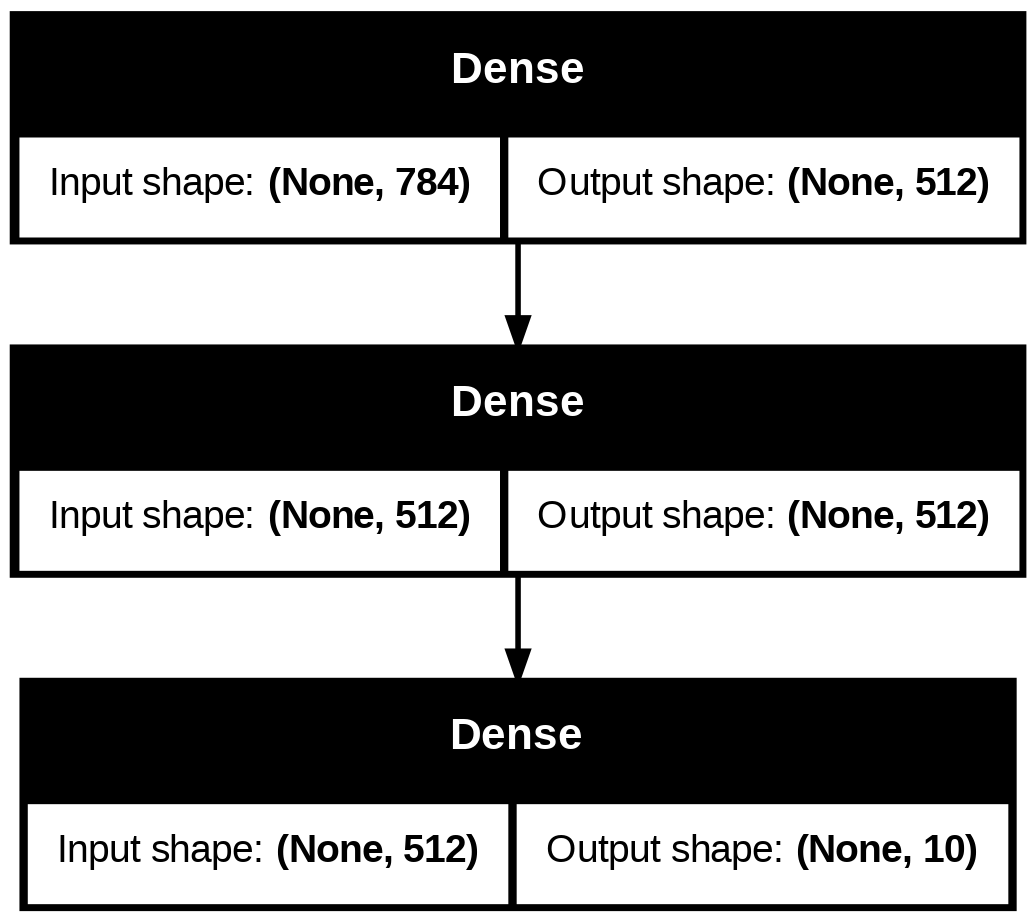

In [14]:

plot_model(model_1, show_shapes=True)


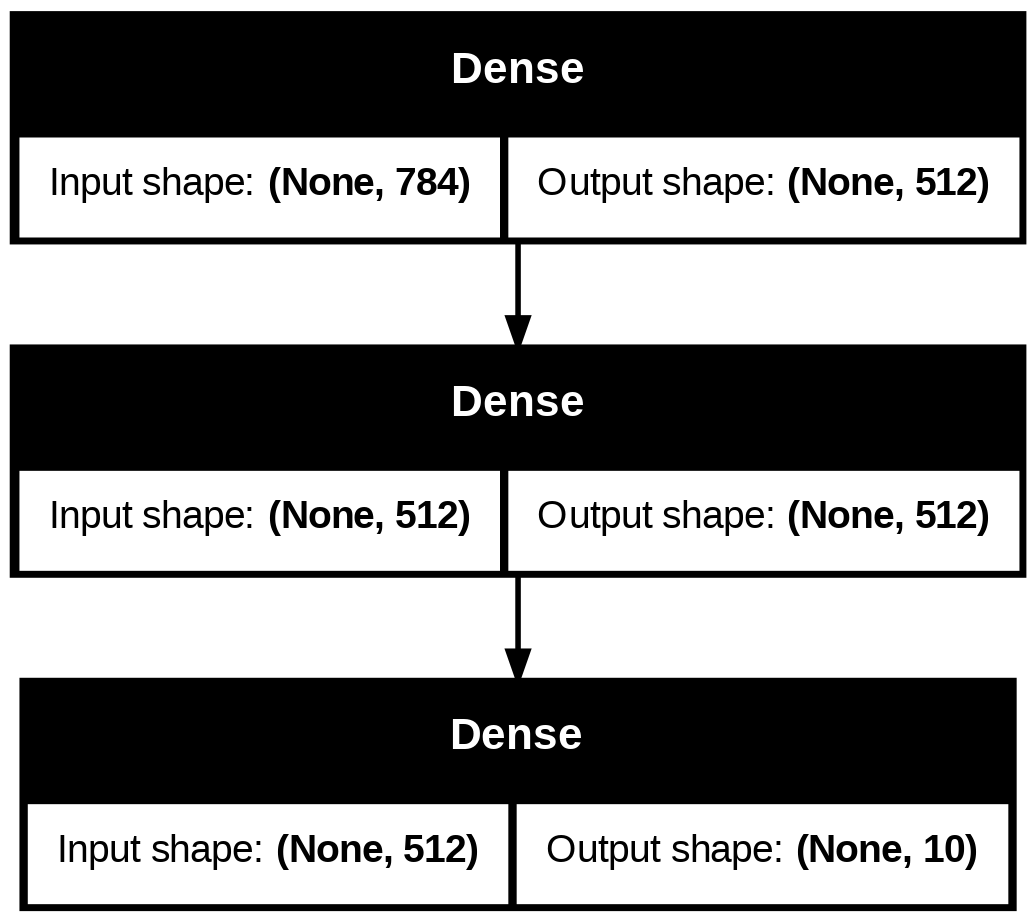

In [15]:

plot_model(model_2, show_shapes=True)


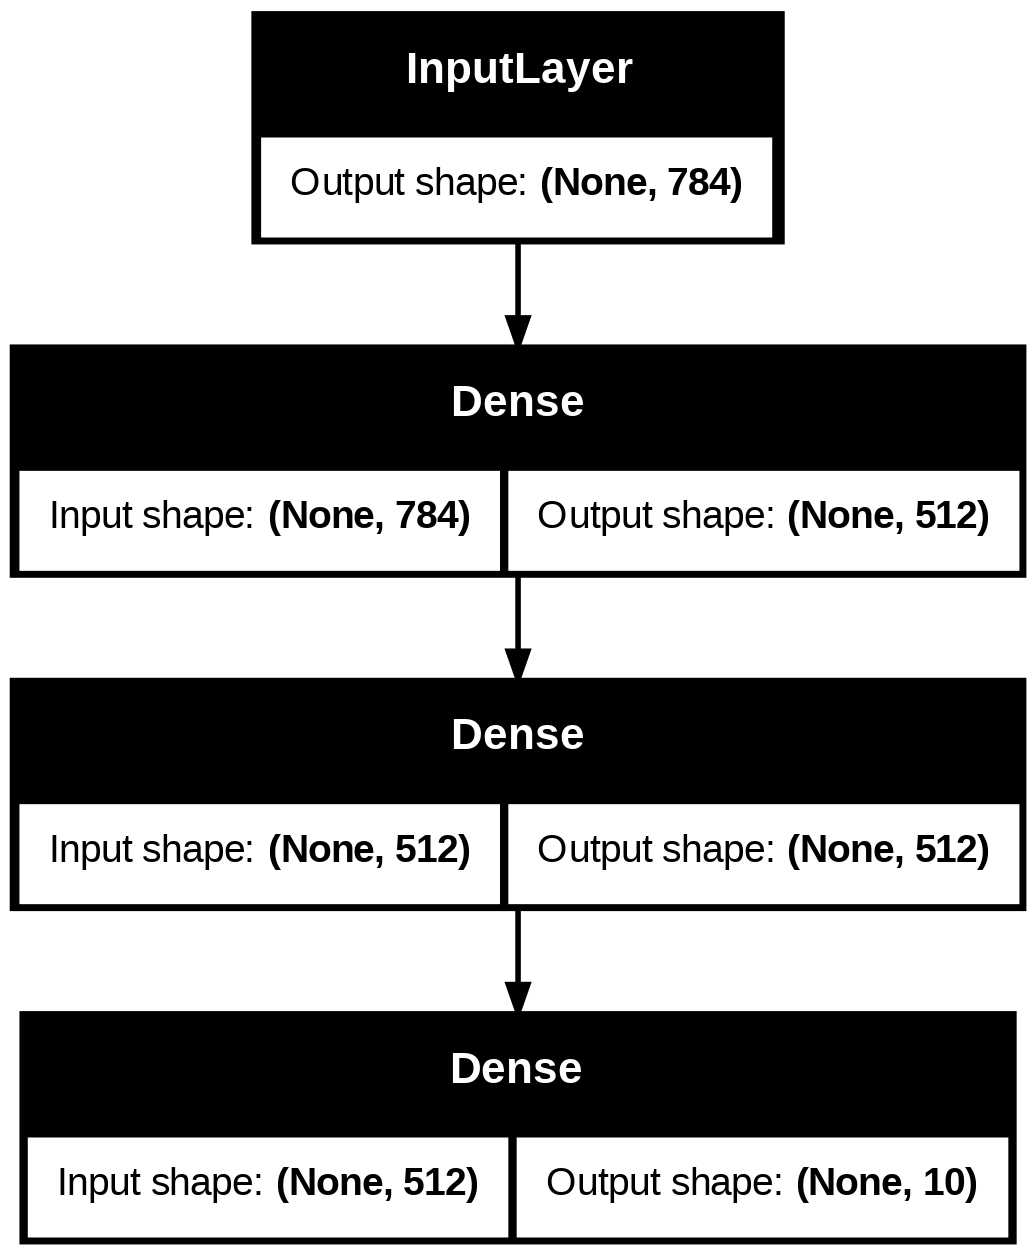

In [16]:

plot_model(model_3, show_shapes=True)


## 3.5 Visualizing models: Visual Keras

In [39]:
# Visualize model...

!pip install visualkeras      # <----------- Important!!! Install library in colab, if necessary
import visualkeras             # Import library
visualkeras.layered_view(model_1, legend=True, to_file='output.png', color_map={'Dense': '#a8c6ea'})

/usr/local/lib/python3.12/dist-packages/visualkeras/layered.py:231: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


AttributeError: 'Dense' object has no attribute 'output_shape'

# 4. MLP training

Now let's train our network. The training process is the same for models created using the sequential model or the API functional model. There are two key functions: the `model.compile`, that specifies the network compitation details, and the `model.fit`, that specifies the data patterns.


## 4.1. Compilaton

Keras is build over Tensorflow, Theano or CNTK, libraries that allow the use of distinct devices (CPU, GPU, etc.). In the compilation phase, Keras requires that you specify some parameters such as:

* **Loss function:** a function that computes the __distance between the current output and the expected output__. Here we will use the *crossentropy*, a function that is particularly suitable for comparing probability distributions. Our predictions are the probability distributions over 10 distinct digits (for example: we are 80% confident that this image belongs to class 3, 10% confident that this image belongs to class 5, 5% to class 9, and so on). Of course, our target is 100% to the correct class and 0% to all the ramaining classes. The crossentropy measures the difference between two probability distributions for a given random variable or set of events.

* **Optimizer:**  function that __modifies the free parameters__ (weights) of the neural network. It determines how fast is the learning, its robustness to plateaus, and so on. In this example we will use a variant of the descent gradient called *Stocastic Gradient Descent (SDG)*. Instead of considering all the training set in all learning steps, SDG only uses a small random portion of the training data in each step.  

* **Metrics:** function that will be adopted to __evaluate our learning__ (accuracy, MSE, MAE...).

In [18]:
# Configurating the training process...

# Setting the seed...
import random as rn
np.random.seed(42)    #starting Numpy generated random numbers...
rn.seed(42)           #starting core Python generated random numbers...


model = model_1

model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizers.SGD(learning_rate=0.01),
    metrics=['accuracy']
    )


## 4.2. Training

Finaly, let's train our model. Some of the arguments of the `model.fit()` function are:

* **X and Y:** the training samples and their labels;
* **batch_size:** instead of applying the *backpropagation* over all the training set, we do it at each batch (a small subset of the training set). In this case we will apply the *backpropagation* at each 128 images;
* **epochs:** how many times the training set will be processed;
* **verbose:** show some metrics after each training epoch. values: 0 (silent), 1 (progress bar), 2 (one line per epoch) or 'auto' (defaults to 1 for most cases, but 2 in some particular cases);
* **class_weight:** the weights of each class, considering that they are not balanced. The learning algorithm will take into consideration how frequent each class is;
* **validation_split:** float between 0 and 1. Fraction of the training data to be used as validation data;
* **validation_data:** allows the use of a particular validation set. After each training epoch, our model will predict the output for the validation set and the validation evaluation will be shown.

**Returns:**

A History object, that is, a record of training loss values and metrics values at successive epochs, as well as validation loss values and validation metrics values (if applicable).

Let's train the network using the __early stop__ as our **stop criteria**:


In [24]:
# --------------------
# Training the NN...
# --------------------

callback = callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0,
    patience=3,  #Number of epochs with no improvement after which training will be stopped
    verbose=2,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
)

model.build()
history_early_stop = model.fit(X_reshaped, Y_onehot, batch_size=128, callbacks=[callback], epochs=500, verbose=2, validation_split=0.2)


Epoch 1/500
375/375 - 7s - 19ms/step - accuracy: 0.9937 - loss: 0.0301 - val_accuracy: 0.9767 - val_loss: 0.0839
Epoch 2/500
375/375 - 8s - 22ms/step - accuracy: 0.9940 - loss: 0.0296 - val_accuracy: 0.9766 - val_loss: 0.0839
Epoch 3/500
375/375 - 7s - 19ms/step - accuracy: 0.9940 - loss: 0.0291 - val_accuracy: 0.9765 - val_loss: 0.0844
Epoch 4/500
375/375 - 5s - 14ms/step - accuracy: 0.9942 - loss: 0.0287 - val_accuracy: 0.9759 - val_loss: 0.0833
Epoch 5/500
375/375 - 5s - 14ms/step - accuracy: 0.9945 - loss: 0.0282 - val_accuracy: 0.9764 - val_loss: 0.0833
Epoch 6/500
375/375 - 7s - 19ms/step - accuracy: 0.9944 - loss: 0.0277 - val_accuracy: 0.9768 - val_loss: 0.0835
Epoch 7/500
375/375 - 8s - 23ms/step - accuracy: 0.9948 - loss: 0.0274 - val_accuracy: 0.9762 - val_loss: 0.0831
Epoch 8/500
375/375 - 7s - 18ms/step - accuracy: 0.9950 - loss: 0.0269 - val_accuracy: 0.9759 - val_loss: 0.0837
Epoch 9/500
375/375 - 5s - 14ms/step - accuracy: 0.9949 - loss: 0.0265 - val_accuracy: 0.9763 - 

Now let's check our training history....

Available keys:  dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


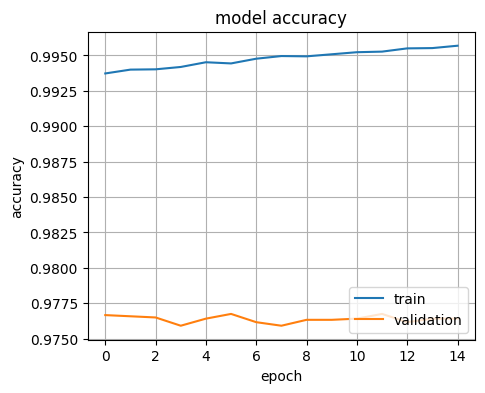

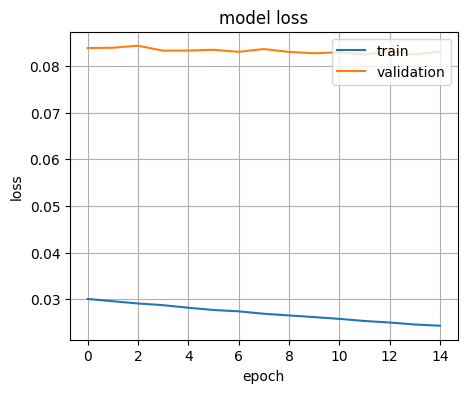

In [25]:
# -----------------------------------------------------
# Creating a function to plot our training history...
# -----------------------------------------------------

def plot_graphs(my_history):

    plt.rcParams['figure.figsize'] = (5,4)          # Display figures smaller...
    # List available data in history
    print("Available keys: ", my_history.history.keys())

    # Plot accuracy history
    plt.plot(my_history.history['accuracy'])
    plt.plot(my_history.history['val_accuracy'])
    plt.title('model accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train', 'validation'], loc='lower right')
    plt.grid()
    plt.show()

    # Plot loss history
    plt.plot(my_history.history['loss'])
    plt.plot(my_history.history['val_loss'])
    plt.title('model loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'validation'], loc='upper right')
    plt.grid()
    plt.show()

# Plotting it...
plot_graphs(history_early_stop)


## 4.3. Balancing classes

Now, let's train with **balanced weights**, that is, let's assign a weight to the examples of all classes:

Epoch 1/500
375/375 - 6s - 15ms/step - accuracy: 0.7169 - loss: 1.3230 - val_accuracy: 0.8683 - val_loss: 0.6287
Epoch 2/500
375/375 - 7s - 18ms/step - accuracy: 0.8737 - loss: 0.5283 - val_accuracy: 0.8972 - val_loss: 0.4060
Epoch 3/500
375/375 - 6s - 16ms/step - accuracy: 0.8927 - loss: 0.4029 - val_accuracy: 0.9078 - val_loss: 0.3424
Epoch 4/500
375/375 - 5s - 14ms/step - accuracy: 0.9042 - loss: 0.3526 - val_accuracy: 0.9139 - val_loss: 0.3102
Epoch 5/500
375/375 - 7s - 20ms/step - accuracy: 0.9107 - loss: 0.3226 - val_accuracy: 0.9182 - val_loss: 0.2885
Epoch 6/500
375/375 - 8s - 21ms/step - accuracy: 0.9162 - loss: 0.3006 - val_accuracy: 0.9217 - val_loss: 0.2741
Epoch 7/500
375/375 - 7s - 19ms/step - accuracy: 0.9201 - loss: 0.2835 - val_accuracy: 0.9267 - val_loss: 0.2596
Epoch 8/500
375/375 - 8s - 22ms/step - accuracy: 0.9242 - loss: 0.2691 - val_accuracy: 0.9297 - val_loss: 0.2481
Epoch 9/500
375/375 - 7s - 20ms/step - accuracy: 0.9278 - loss: 0.2566 - val_accuracy: 0.9324 - 

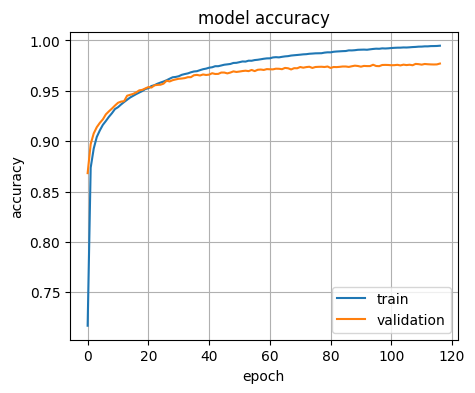

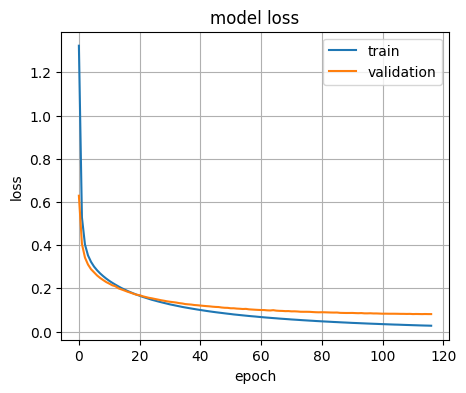

In [26]:
# Training the network with early stop and balanced weights

# Keras clone_model function creates a cloned network with the same architecture but new weights
model = tensorflow.keras.models.clone_model(model)

model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizers.SGD(learning_rate=0.01),
    metrics=['accuracy']
    )

callback = callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0,
    patience=3,  #Number of epochs with no improvement after which training will be stopped
    verbose=2,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
)

model.build()

history_balanced_weights = model.fit(X_reshaped, Y_onehot, batch_size=128, class_weight = class_weights, callbacks=[callback], epochs=500, verbose=2, validation_split=0.2)

plot_graphs(history_balanced_weights)


In [27]:
# Comparing balanced and unbalanced classes...

print("Unbalanced classes ---> Training loss:", history_early_stop.history['loss'][-1], " Validation loss: ", history_early_stop.history['val_loss'][-1])
print("Balanced classes   ---> Training loss:", history_balanced_weights.history['loss'][-1], " Validation loss: ", history_balanced_weights.history['val_loss'][-1])


Unbalanced classes ---> Training loss: 0.02431880123913288  Validation loss:  0.08308146148920059
Balanced classes   ---> Training loss: 0.027080610394477844  Validation loss:  0.08092036098241806


## 4.4. Evaluation

### 4.4.1. Test set error rate

Lets check the NN evaluation to the __test set__...

In [28]:
# NN evaluation to the test set...

test_scores = model.evaluate(X_test_reshaped, Y_test_onehot, verbose=2)
print("Test loss:", test_scores[0])
print("Test accuracy:", test_scores[1])


313/313 - 2s - 5ms/step - accuracy: 0.9779 - loss: 0.0718
Test loss: 0.07178916037082672
Test accuracy: 0.9779000282287598


Our approach reached a __~97,7%__ accuracy, and, therefore, a __~2,3% error rate__. According to the literature, MLP-based approaches applyed to the MNIST dataset usually achieve error rates between __4,7%__ (2-layer NN, 300 hidden neurons) and __0,35%__ (6-layer NN, hidden neurons: 2500-2000-1500-1000-500-10 with elastic distortions).

### 4.4.2. Confusion Matrix

Now, let's check the NN __confusion_matrix__...

In [29]:
# NN Confusion Matrix...

Y_pred = model.predict(X_test_reshaped)
matrix = tensorflow.math.confusion_matrix (Y_test_onehot.argmax(axis=1), Y_pred.argmax(axis=1))

import pandas as pd
NN_confusion_matrix = pd.DataFrame(matrix.numpy())
NN_confusion_matrix = NN_confusion_matrix.style.background_gradient(cmap='Blues',axis=1)
NN_confusion_matrix


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


,0,1,2,3,4,5,6,7,8,9
0,969,0,1,1,2,1,1,2,2,1
1,0,1122,3,1,0,1,4,1,3,0
2,3,1,1009,2,2,0,1,6,8,0
3,1,0,4,992,0,1,0,6,3,3
4,1,0,3,1,959,0,3,4,0,11
5,5,0,0,6,0,865,6,1,6,3
6,6,3,1,0,2,3,941,0,2,0
7,2,4,7,3,0,0,0,1007,2,3
8,4,0,6,6,4,3,3,5,943,0
9,3,3,2,7,10,1,1,8,2,972


## 5. Deep Neural Network (DNN)

Now let's use a DNN to classify our database!

In [30]:
# More libraries...

from __future__ import print_function
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import datasets
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras import backend as K


### 5.1. Architecture

Let's consider a CNN with the following layers:

* Conv2D:
   * Number of filters: 64
   * Kernel size: (3,3)
   * Activation function: 'relu'
* MaxPooling2D:
   * Pool size: (2,2)
   * Strides: (2,2)
   

In [31]:

# Creating a DNN sequential model...

# Creating the network....
image_shape = (len(X_train[0][0]), len(X_train[0][1]), 1)     # Get our 28x28 image
model_dnn = Sequential(name="model_dnn")

# Convolutional layers:
model_dnn.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu', input_shape=image_shape, use_bias=True, name="layer1"))
model_dnn.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2), name="layer2"))
model_dnn.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu', use_bias=True, name="layer3"))
model_dnn.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2), name="layer4"))

# Dense layers:
model_dnn.add(Flatten(name="layer5"))
model_dnn.add(Dense(200, activation="relu", name="layer6"))
model_dnn.add(Dense(200, activation="relu", name="layer7"))
model_dnn.add(Dense(NUM_CLASSES, activation="softmax", name="layer8"))

model_dnn.build()
model_dnn.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "model_dnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer1 (Conv2D)                 │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (MaxPooling2D)           │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer3 (Conv2D)                 │ (None, 11, 11, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer4 (MaxPooling2D)           │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer5 (Flatten)                │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer6 (Dense)                  │ (None, 200)            │       320,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer7 (Dense)                  │ (None, 200)            │        40,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer8 (Dense)                  │ (None, 10)             │         2,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 399,978 (1.53 MB)

 Trainable params: 399,978 (1.53 MB)

 Non-trainable params: 0 (0.00 B)

Let's understand our convolutional architecture...

<div><center><img src="https://drive.google.com/uc?id=1aHES369pY0nyRyCb2XCITavWvb2_ZBBE" width="1000"></center></div>

## 5.2. Visualizing model: Keras

Let's visualize our CNN using Keras:

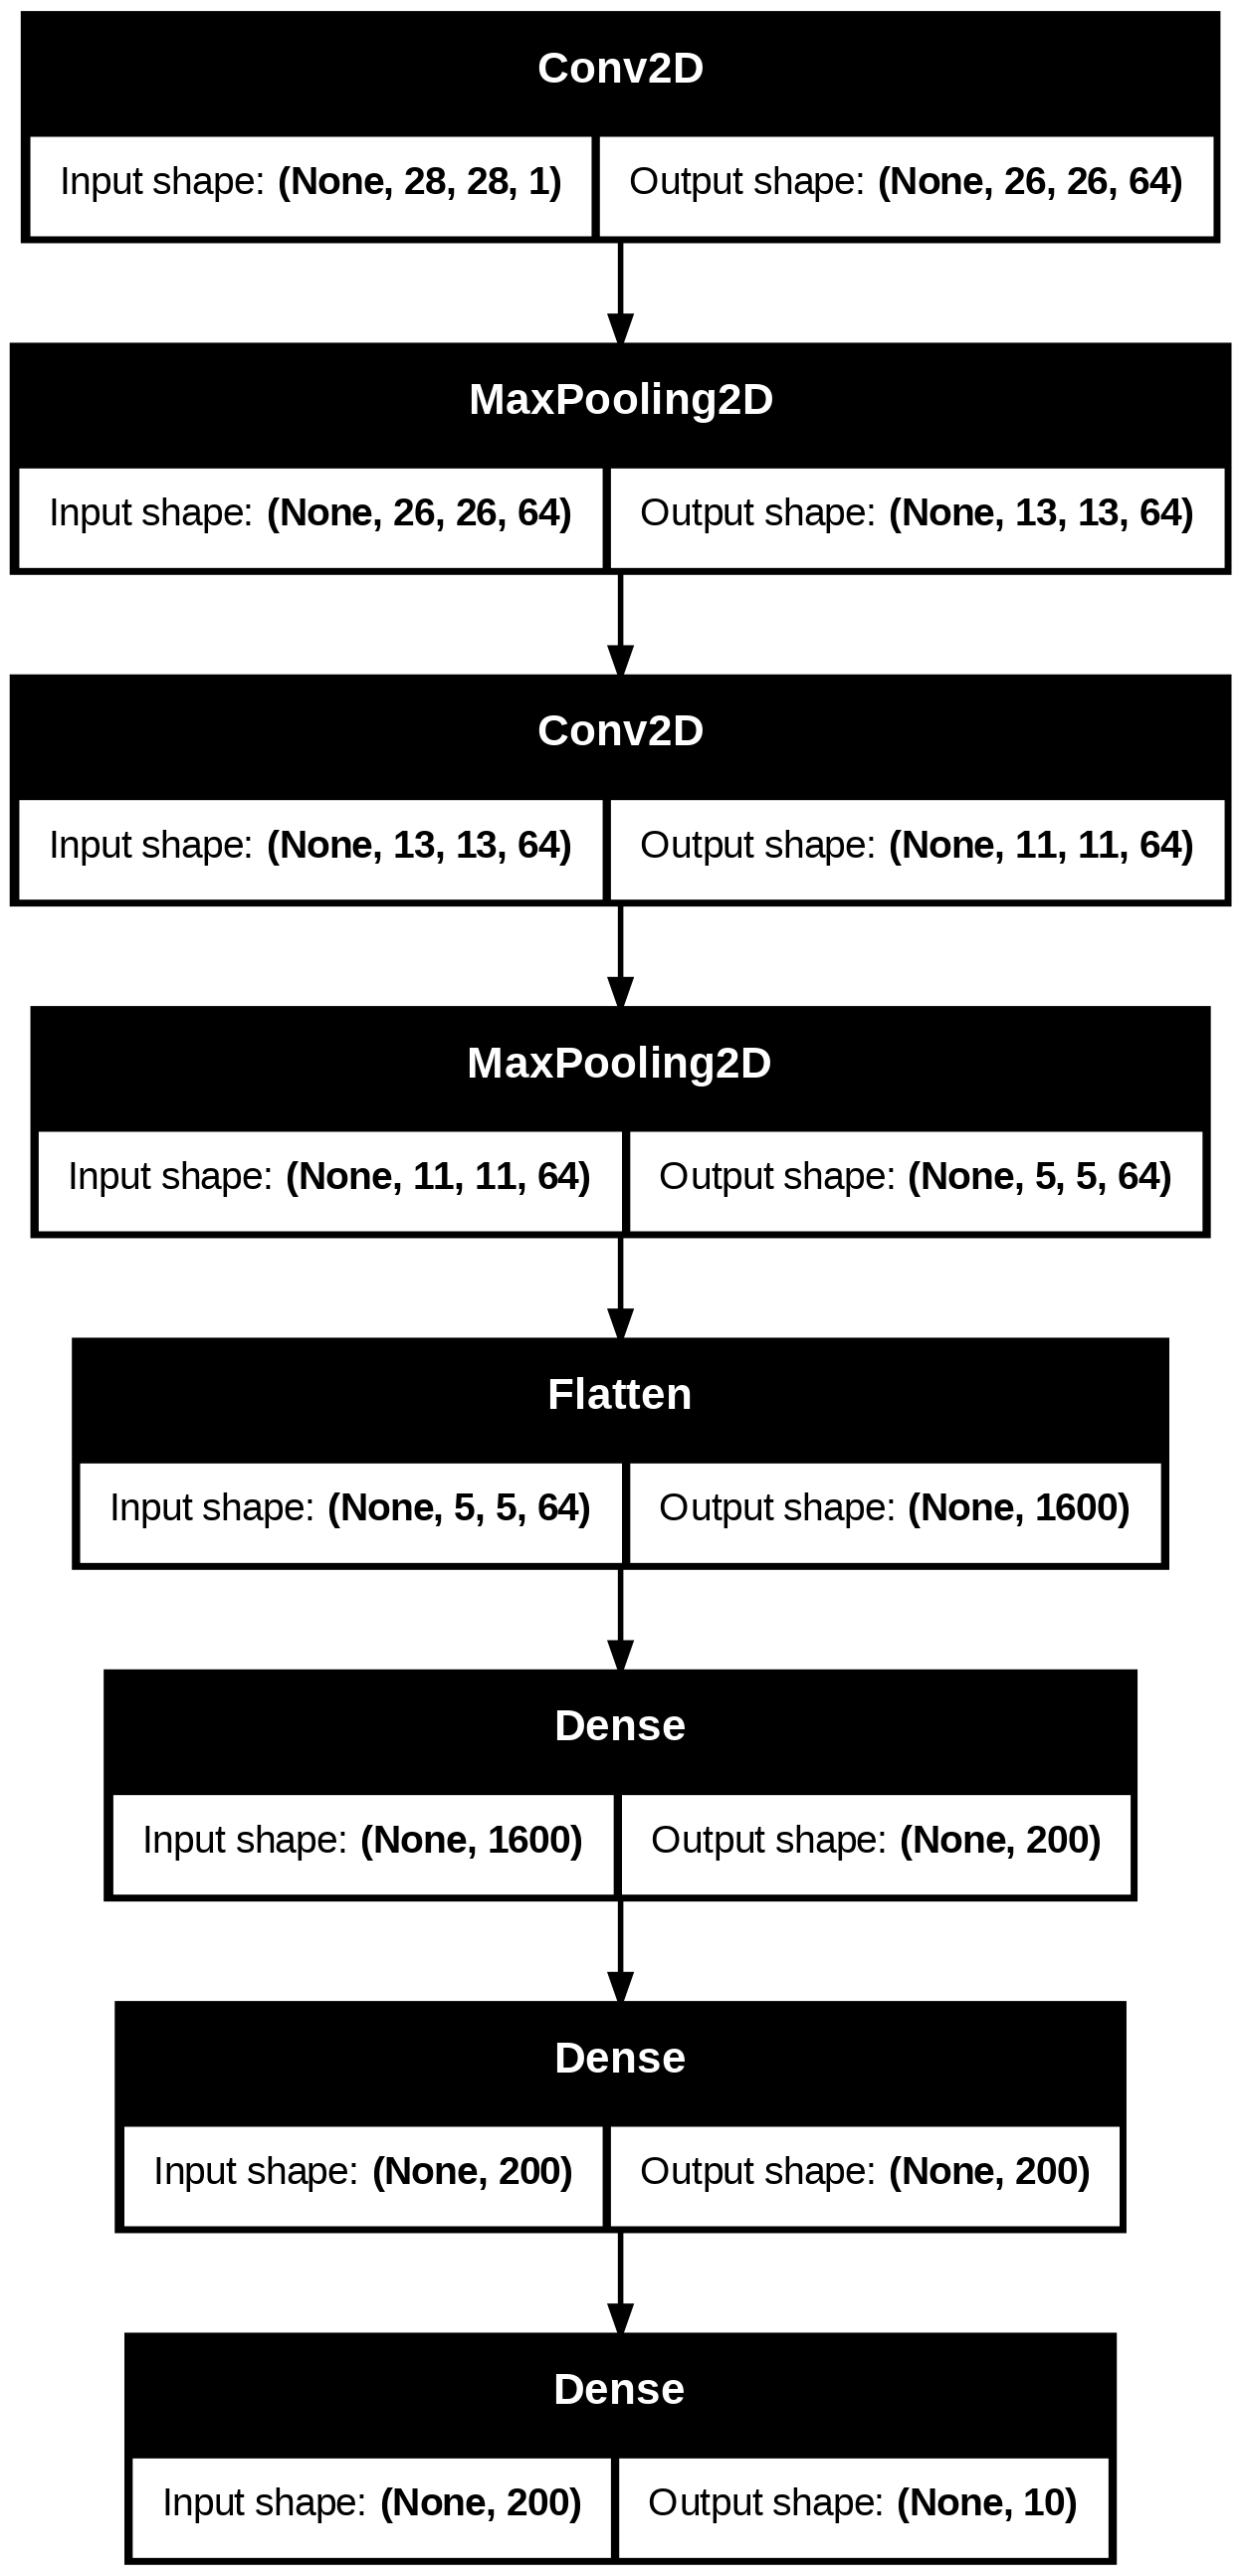

In [32]:

from tensorflow.keras.utils import plot_model
plot_model(model_dnn, "model_dnn.png", show_shapes=True)


## 5.3. Visualizing model: Visual Keras

Now using Visual Keras:

In [41]:
# Visualize model...
import visualkeras
import numpy as np

# Pass a dummy input to the model to ensure all layer shapes are inferred
dummy_input = np.random.rand(1, 28, 28, 1) # model_dnn expects input_shape=(28, 28, 1)
_ = model_dnn(dummy_input)

visualkeras.layered_view(model_dnn, legend=True)

AttributeError: 'Conv2D' object has no attribute 'output_shape'

# 6. DNN Training

## 6.2. Compilation

Some of the model __compiler__ options are:

* __<a href="https://www.tensorflow.org/api_docs/python/tf/keras/losses" target="_new">loss functions</a>__:

   * `BinaryCrossentropy`: Computes the cross-entropy loss between true labels and predicted labels
   * `CategoricalCrossentropy`: Computes the crossentropy loss between the labels and predictions.
   * `CategoricalHinge`: Computes the categorical hinge loss between y_true and y_pred.
   * `CosineSimilarity`: Computes the cosine similarity between labels and predictions.
   * `Hinge`: Computes the hinge loss between y_true and y_pred.
   * `Huber`: Computes the Huber loss between y_true and y_pred.
   * `KLDivergence`: Computes Kullback-Leibler divergence loss between y_true and y_pred.
   * `LogCosh`: Computes the logarithm of the hyperbolic cosine of the prediction error.
   * `Loss`: Loss base class.
   * `MeanAbsoluteError`: Computes the mean of absolute difference between labels and predictions.
   * `MeanAbsolutePercentageError`: Computes the mean absolute percentage error between y_true and y_pred.
   * `MeanSquaredError`: Computes the mean of squares of errors between labels and predictions.
   * `MeanSquaredLogarithmicError`: Computes the mean squared logarithmic error between y_true and y_pred.
   * `Poisson`: Computes the Poisson loss between y_true and y_pred.
   * `Reduction`: Types of loss reduction.
   * `SparseCategoricalCrossentropy`: Computes the crossentropy loss between the labels and predictions.
   * `SquaredHinge`: Computes the squared hinge loss between y_true and y_pred.

* __<a href="https://www.tensorflow.org/api_docs/python/tf/keras/metrics" target="_new">Metrics</a>__ to evaluate model:

   * `class AUC`: Computes the approximate AUC (Area under the curve) via a Riemann sum.
   * `class Accuracy`: Calculates how often predictions equals labels.
   * `BinaryAccuracy`: Calculates how often predictions matches binary labels.
   * `BinaryCrossentropy`: Computes the crossentropy metric between the labels and predictions.
   * `CategoricalAccuracy`: Calculates how often predictions matches one-hot labels.
   * `CategoricalCrossentropy`: Computes the crossentropy metric between the labels and predictions.
   * `CategoricalHinge`: Computes the categorical hinge metric between y_true and y_pred.
   * `CosineSimilarity`: Computes the cosine similarity between the labels and predictions.
   * `FalseNegatives`: Calculates the number of false negatives.
   * `FalsePositives`: Calculates the number of false positives.
   * `Hinge`: Computes the hinge metric between y_true and y_pred.
   * `KLDivergence`: Computes Kullback-Leibler divergence metric between y_true and y_pred.
   * `LogCoshError`: Computes the logarithm of the hyperbolic cosine of the prediction error.
   * `Mean`: Computes the (weighted) mean of the given values.
   * `MeanAbsoluteError`: Computes the mean absolute error between the labels and predictions.
   * `MeanAbsolutePercentageError`: Computes the mean absolute percentage error between y_true and y_pred.
   * `MeanIoU`: Computes the mean Intersection-Over-Union metric.
   * `MeanRelativeError`: Computes the mean relative error by normalizing with the given values.
   * `MeanSquaredError`: Computes the mean squared error between y_true and y_pred.
   * `MeanSquaredLogarithmicError`: Computes the mean squared logarithmic error between y_true and y_pred.
   * `MeanTensor`: Computes the element-wise (weighted) mean of the given tensors.
   * `Metric`: Encapsulates metric logic and state.
   * `Poisson`: Computes the Poisson metric between y_true and y_pred.
   * `Precision`: Computes the precision of the predictions with respect to the labels.
   * `PrecisionAtRecall`: Computes best precision where recall is >= specified value.
   * `Recall`: Computes the recall of the predictions with respect to the labels.
   * `RecallAtPrecision`: Computes best recall where precision is >= specified value.
   * `RootMeanSquaredError`: Computes root mean squared error metric between y_true and y_pred.
   * `SensitivityAtSpecificity`: Computes best sensitivity where specificity is >= specified value.
   * `SparseCategoricalAccuracy`: Calculates how often predictions matches integer labels.
   * `SparseCategoricalCrossentropy`: Computes the crossentropy metric between the labels and predictions.
   * `SparseTopKCategoricalAccuracy`: Computes how often integer targets are in the top K predictions.
   * `SpecificityAtSensitivity`: Computes best specificity where sensitivity is >= specified value.
   * `SquaredHinge`: Computes the squared hinge metric between y_true and y_pred.
   * `Sum`: Computes the (weighted) sum of the given values.
   * `TopKCategoricalAccuracy`: Computes how often targets are in the top K predictions.
   * `TrueNegatives`: Calculates the number of true negatives.
   * `TruePositives`: Calculates the number of true positives.
  
*  __<a href="https://www.tensorflow.org/api_docs/python/tf/keras/optimizers" target="_new">Optimizers</a>__:

   * `Adadelta` algorithm
   * `Adagrad` algorithm
   * `Adam` algorithm
   * `Adamax` algorithm
   * `Ftrl` algorithm
   * `Nadam` algorithm
   * `Optimizer` algorithm
   * `RMSprop` algorithm
   * `SGD` Gradient descent (with momentum) algorithm
   
Let's compile our model with the __early stop__:

Epoch 1/500
375/375 - 87s - 231ms/step - accuracy: 0.5664 - loss: 1.5005 - val_accuracy: 0.8553 - val_loss: 0.4848
Epoch 2/500
375/375 - 73s - 194ms/step - accuracy: 0.8814 - loss: 0.3914 - val_accuracy: 0.9157 - val_loss: 0.2773
Epoch 3/500
375/375 - 81s - 217ms/step - accuracy: 0.9161 - loss: 0.2732 - val_accuracy: 0.9341 - val_loss: 0.2171
Epoch 4/500
375/375 - 71s - 189ms/step - accuracy: 0.9352 - loss: 0.2110 - val_accuracy: 0.9517 - val_loss: 0.1710
Epoch 5/500
375/375 - 85s - 227ms/step - accuracy: 0.9468 - loss: 0.1724 - val_accuracy: 0.9582 - val_loss: 0.1467
Epoch 6/500
375/375 - 79s - 211ms/step - accuracy: 0.9561 - loss: 0.1463 - val_accuracy: 0.9652 - val_loss: 0.1228
Epoch 7/500
375/375 - 83s - 222ms/step - accuracy: 0.9619 - loss: 0.1273 - val_accuracy: 0.9677 - val_loss: 0.1175
Epoch 8/500
375/375 - 81s - 216ms/step - accuracy: 0.9654 - loss: 0.1133 - val_accuracy: 0.9696 - val_loss: 0.1069
Epoch 9/500
375/375 - 73s - 196ms/step - accuracy: 0.9683 - loss: 0.1044 - val_a

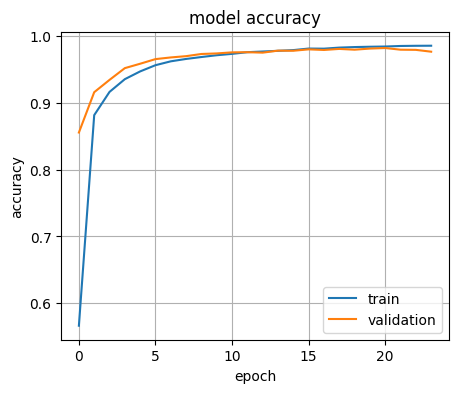

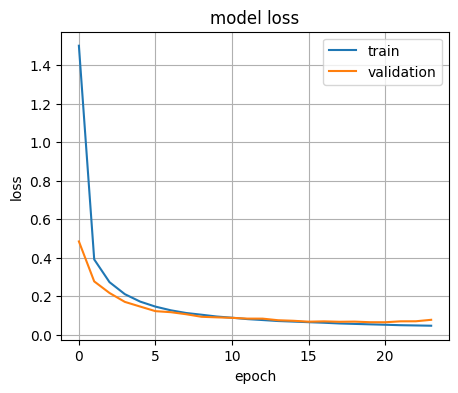

In [34]:
# Compiling the model...

model_dnn.compile(
    loss='categorical_crossentropy',
    optimizer=optimizers.SGD(learning_rate=0.01),
    metrics=['accuracy'])

callback = callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0,
    patience=3,  #Number of epochs with no improvement after which training will be stopped
    verbose=2,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
)

history_dnn = model_dnn.fit(X_train, Y_onehot, batch_size=128, callbacks=[callback], epochs=500, verbose=2, validation_split=0.2)
plot_graphs(history_dnn)



## 6.2. Evaluation

Let's evaluate our DNN with the __test set__ :

In [35]:

# Evaluating the DNN....

score = model_dnn.evaluate(X_test, Y_test_onehot, verbose=0)

print('Test loss:', score[0])
print('Test accuracy:', score[1])


Test loss: 0.06164677068591118
Test accuracy: 0.9801999926567078


Our approach reached a __~98,4%__ accuracy, and, therefore, a __~1,6%__ error rate. According to the literature, CNN-based approaches applyed to the MNIST dataset usually achieve error rates between __1,7%__ (Convolutional net LeNet-1) and __0,23%__ (committee of 35 conv. net, 1-20-P-40-P-150-10 with elastic distortions).

Now let's check our __confusion matrix__ :

In [36]:

# Display the DNN confusion matrix...

Y_pred = model_dnn.predict(X_test)
matrix = tensorflow.math.confusion_matrix (Y_test_onehot.argmax(axis=1), Y_pred.argmax(axis=1))

DNN_confusion_matrix = pd.DataFrame(matrix.numpy())
DNN_confusion_matrix = DNN_confusion_matrix.style.background_gradient(cmap='Reds',axis=1)
DNN_confusion_matrix


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


,0,1,2,3,4,5,6,7,8,9
0,970,0,0,0,0,2,1,2,4,1
1,0,1126,0,3,0,0,2,1,3,0
2,3,3,998,11,1,0,0,5,10,1
3,0,0,0,1000,0,3,0,0,3,4
4,0,0,1,0,944,0,1,2,1,33
5,1,0,0,8,0,877,3,1,1,1
6,2,2,0,1,1,6,945,0,1,0
7,1,2,4,7,0,0,0,989,2,23
8,3,0,1,6,1,1,0,1,954,7
9,1,2,0,2,2,3,0,0,0,999


Let's compare to the __MLP__ confusion matrix:

In [37]:

# Showing the MLP confusion matrix...
NN_confusion_matrix


,0,1,2,3,4,5,6,7,8,9
0,969,0,1,1,2,1,1,2,2,1
1,0,1122,3,1,0,1,4,1,3,0
2,3,1,1009,2,2,0,1,6,8,0
3,1,0,4,992,0,1,0,6,3,3
4,1,0,3,1,959,0,3,4,0,11
5,5,0,0,6,0,865,6,1,6,3
6,6,3,1,0,2,3,941,0,2,0
7,2,4,7,3,0,0,0,1007,2,3
8,4,0,6,6,4,3,3,5,943,0
9,3,3,2,7,10,1,1,8,2,972


## 7. Final considerations

Some topics to think about....
* The neural networks are able to correclty classify any kind of digits images?
* What are the most common DNN architectures used for image classification tasks?
* How are these architectures evolving?
* Some topics for research:
    * AlexNet
    * VGG16
    * GoogleNet
    * The invariance problem
    * Data augmentation
    

____
<center>
<img src="https://upload.wikimedia.org/wikipedia/commons/0/0a/Logo_Unesp.svg" width="400" style="float: left; margin-right: 5px;" border="0px" />
</center>